# Model Evaluation

This notebook evaluates the recommendation outputs built in **02_recommender_build.ipynb**.

It focuses on practical offline checks:
- holdout-style hit rate evaluation
- recommendation coverage
- category diversity
- popularity bias
- persona-level recommendation patterns


## 1. Imports and paths

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display


In [2]:
cwd = Path.cwd()

if (cwd / 'data' / 'raw').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data' / 'raw').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError('Could not find data/raw from the current notebook location.')

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
FIG_DIR = PROJECT_ROOT / 'results' / 'figures'
METRICS_DIR = PROJECT_ROOT / 'results' / 'metrics'

FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Processed dir:', PROCESSED_DIR)
print('Models dir:', MODELS_DIR)


Project root: C:\Users\Owen\Documents\Hertsfordshire\Projects\personalized-content
Processed dir: C:\Users\Owen\Documents\Hertsfordshire\Projects\personalized-content\data\processed
Models dir: C:\Users\Owen\Documents\Hertsfordshire\Projects\personalized-content\models


## 2. Load processed data and model assets

In [3]:
users = pd.read_csv(RAW_DIR / 'users.csv')
content = pd.read_csv(RAW_DIR / 'content.csv')
interactions = pd.read_csv(RAW_DIR / 'interactions.csv')
interactions['interaction_timestamp'] = pd.to_datetime(interactions['interaction_timestamp'])

content_features = pd.read_csv(PROCESSED_DIR / 'content_features.csv')
user_profiles = pd.read_csv(PROCESSED_DIR / 'user_profiles.csv')
interaction_scores = pd.read_csv(PROCESSED_DIR / 'interaction_scores.csv')
interaction_scores['interaction_timestamp'] = pd.to_datetime(interaction_scores['interaction_timestamp'])

with open(MODELS_DIR / 'similarity_matrix.pkl', 'rb') as f:
    similarity_matrix = pickle.load(f)

with open(MODELS_DIR / 'recommender_assets.pkl', 'rb') as f:
    assets = pickle.load(f)

top_popular = assets['top_popular']
content_index = assets['content_index']
seen_lookup_full = assets['seen_lookup']

print('Loaded files successfully.')
print('content_features:', content_features.shape)
print('interaction_scores:', interaction_scores.shape)


Loaded files successfully.
content_features: (900, 19)
interaction_scores: (22000, 17)


## 3. Rebuild helper functions for evaluation

In [4]:
content_index_series = pd.Series(content_features.index, index=content_features['content_id']).drop_duplicates()

content_popularity_lookup = top_popular[['content_id', 'popularity_rank_score']].copy()
max_pop = content_popularity_lookup['popularity_rank_score'].max()
content_popularity_lookup['normalized_popularity_score'] = content_popularity_lookup['popularity_rank_score'] / max_pop
content_popularity_lookup = content_popularity_lookup[['content_id', 'normalized_popularity_score']]

content_meta = content_features[['content_id', 'title', 'category', 'format', 'mood']].copy()
user_lookup = users.set_index('user_id').to_dict('index')

def get_similar_items_eval(content_id, top_n=50):
    if content_id not in content_index_series.index:
        return pd.DataFrame()
    idx = content_index_series[content_id]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    indices = [x[0] for x in sim_scores]
    scores = [x[1] for x in sim_scores]
    out = content_features.iloc[indices][['content_id', 'title', 'category', 'format', 'mood']].copy()
    out['content_similarity_score'] = scores
    return out

def get_seed_items_from_train(train_df, user_id, top_k=3):
    user_rows = train_df[train_df['user_id'] == user_id].copy()
    user_rows = user_rows[
        (user_rows['engagement_score'] >= 6) |
        (user_rows['liked'] == 1) |
        (user_rows['saved'] == 1) |
        (user_rows['completed'] == 1)
    ]
    if user_rows.empty:
        return []
    user_rows = user_rows.sort_values('engagement_score', ascending=False)
    return user_rows.drop_duplicates('content_id').head(top_k)['content_id'].tolist()

def recommend_for_user_from_train(user_id, train_df, top_n=10):
    seen_items = set(train_df.loc[train_df['user_id'] == user_id, 'content_id'].tolist())
    seed_items = get_seed_items_from_train(train_df, user_id, top_k=3)

    if not seed_items:
        fallback = top_popular.loc[~top_popular['content_id'].isin(seen_items)].head(top_n).copy()
        fallback['final_score'] = fallback['popularity_rank_score']
        fallback['recommendation_reason'] = 'popularity fallback'
        return fallback[['content_id', 'title', 'category', 'format', 'final_score', 'recommendation_reason']]

    candidates = []
    for seed in seed_items:
        sims = get_similar_items_eval(seed, top_n=60)
        if not sims.empty:
            sims['seed_content_id'] = seed
            candidates.append(sims)

    if not candidates:
        fallback = top_popular.loc[~top_popular['content_id'].isin(seen_items)].head(top_n).copy()
        fallback['final_score'] = fallback['popularity_rank_score']
        fallback['recommendation_reason'] = 'popularity fallback'
        return fallback[['content_id', 'title', 'category', 'format', 'final_score', 'recommendation_reason']]

    candidates = pd.concat(candidates, ignore_index=True)
    candidates = candidates[~candidates['content_id'].isin(seen_items)].copy()

    if candidates.empty:
        fallback = top_popular.loc[~top_popular['content_id'].isin(seen_items)].head(top_n).copy()
        fallback['final_score'] = fallback['popularity_rank_score']
        fallback['recommendation_reason'] = 'popularity fallback'
        return fallback[['content_id', 'title', 'category', 'format', 'final_score', 'recommendation_reason']]

    candidates = (
        candidates.groupby(['content_id', 'title', 'category', 'format', 'mood'], as_index=False)
        .agg(content_similarity_score=('content_similarity_score', 'mean'))
    )
    candidates = candidates.merge(content_popularity_lookup, on='content_id', how='left')
    candidates['normalized_popularity_score'] = candidates['normalized_popularity_score'].fillna(0)

    user_row = user_lookup[user_id]
    fav_categories = set(str(user_row['favorite_categories']).split('|'))
    pref_formats = set(str(user_row['preferred_formats']).split('|'))
    pref_moods = set(str(user_row['preferred_moods']).split('|'))

    candidates['profile_match_score'] = (
        candidates['category'].isin(fav_categories).astype(int) * 0.5 +
        candidates['format'].isin(pref_formats).astype(int) * 0.3 +
        candidates['mood'].isin(pref_moods).astype(int) * 0.2
    )

    candidates['final_score'] = (
        0.55 * candidates['content_similarity_score'] +
        0.25 * candidates['normalized_popularity_score'] +
        0.20 * candidates['profile_match_score']
    )

    def build_reason(row):
        parts = []
        if row['category'] in fav_categories:
            parts.append('favorite category')
        if row['format'] in pref_formats:
            parts.append('preferred format')
        if row['mood'] in pref_moods:
            parts.append('preferred mood')
        if not parts:
            parts.append('similar engaged content')
        return '; '.join(parts)

    candidates['recommendation_reason'] = candidates.apply(build_reason, axis=1)
    return candidates.sort_values('final_score', ascending=False).head(top_n).reset_index(drop=True)


## 4. Build a leave-one-out evaluation set

In [5]:
positive_events = interaction_scores[
    (interaction_scores['engagement_score'] >= 6) |
    (interaction_scores['liked'] == 1) |
    (interaction_scores['saved'] == 1) |
    (interaction_scores['completed'] == 1)
].copy()

positive_counts = positive_events.groupby('user_id')['interaction_id'].count()
eligible_users = positive_counts[positive_counts >= 3].index.tolist()

positive_events = positive_events[positive_events['user_id'].isin(eligible_users)].copy()
positive_events = positive_events.sort_values(['user_id', 'interaction_timestamp'])

holdout_idx = positive_events.groupby('user_id').tail(1).index
holdout_df = positive_events.loc[holdout_idx].copy()
train_df = interaction_scores.drop(index=holdout_idx, errors='ignore').copy()

print('Eligible users:', len(eligible_users))
print('Train rows:', train_df.shape[0])
print('Holdout rows:', holdout_df.shape[0])
display(holdout_df.head())


Eligible users: 450
Train rows: 21550
Holdout rows: 450


,interaction_id,user_id,content_id,viewed,liked,saved,shared,completed,dwell_time_percent,rating,engaged_minutes,interaction_timestamp,engagement_score,interaction_day_type,recommendation_surface,rating_filled,engagement_bucket
15741,I015742,U0001,C0386,1,1,0,0,1,52,NaN,14.0,2026-02-27 11:36:00,8.04,Weekday,Because You Liked,0.0,High
14328,I014329,U0002,C0117,1,1,1,0,1,60,NaN,24.0,2026-03-07 12:16:00,11.20,Weekend,Trending,0.0,Very High
5477,I005478,U0003,C0738,1,0,0,0,1,91,NaN,1.0,2026-03-10 10:08:00,6.32,Weekday,For You,0.0,High
17105,I017106,U0004,C0695,1,0,1,0,0,23,3.0,2.3,2026-03-06 13:38:00,6.86,Weekday,Home Feed,3.0,High
5907,I005908,U0005,C0450,1,0,1,0,0,20,4.0,2.2,2026-03-01 10:20:00,7.60,Weekend,Home Feed,4.0,High


## 5. Offline recommendation evaluation

In [6]:
eval_rows = []

for user_id in eligible_users:
    holdout_item = holdout_df.loc[holdout_df['user_id'] == user_id, 'content_id'].iloc[0]
    recs = recommend_for_user_from_train(user_id, train_df, top_n=10).copy()
    rec_list = recs['content_id'].tolist()
    hit_at_5 = int(holdout_item in rec_list[:5])
    hit_at_10 = int(holdout_item in rec_list[:10])
    reciprocal_rank = 0.0
    if holdout_item in rec_list:
        reciprocal_rank = 1 / (rec_list.index(holdout_item) + 1)

    eval_rows.append({
        'user_id': user_id,
        'holdout_content_id': holdout_item,
        'hit_at_5': hit_at_5,
        'hit_at_10': hit_at_10,
        'reciprocal_rank': reciprocal_rank,
        'top_10_recommendations': '|'.join(rec_list)
    })

evaluation_df = pd.DataFrame(eval_rows)
evaluation_df.head()


,user_id,holdout_content_id,hit_at_5,hit_at_10,reciprocal_rank,top_10_recommendations
0,U0001,C0386,1,1,1.0,C0386|C0709|C0382|C0865|C0400|C0389|C0307|C022...
1,U0002,C0117,0,0,0.0,C0154|C0463|C0716|C0184|C0363|C0793|C0412|C060...
2,U0003,C0738,0,0,0.0,C0741|C0018|C0897|C0626|C0058|C0786|C0683|C023...
3,U0004,C0695,0,0,0.0,C0835|C0717|C0094|C0900|C0357|C0318|C0713|C022...
4,U0005,C0450,0,0,0.0,C0100|C0110|C0367|C0233|C0135|C0474|C0251|C045...


In [7]:
hit_rate_at_5 = evaluation_df['hit_at_5'].mean()
hit_rate_at_10 = evaluation_df['hit_at_10'].mean()
mrr_at_10 = evaluation_df['reciprocal_rank'].mean()

summary_metrics = pd.DataFrame({
    'metric': ['Hit Rate@5', 'Hit Rate@10', 'MRR@10', 'Evaluated Users'],
    'value': [hit_rate_at_5, hit_rate_at_10, mrr_at_10, len(evaluation_df)]
})
summary_metrics


,metric,value
0,Hit Rate@5,0.028889
1,Hit Rate@10,0.035556
2,MRR@10,0.015019
3,Evaluated Users,450.000000


## 6. Coverage, diversity, and popularity bias

In [8]:
all_recommended_items = []
recommendation_snapshots = []

sample_eval_users = eligible_users[:200]

for user_id in sample_eval_users:
    recs = recommend_for_user_from_train(user_id, train_df, top_n=10).copy()
    recs['user_id'] = user_id
    recommendation_snapshots.append(recs)
    all_recommended_items.extend(recs['content_id'].tolist())

recommendation_snapshot_df = pd.concat(recommendation_snapshots, ignore_index=True)

coverage = len(set(all_recommended_items)) / content_features['content_id'].nunique()

category_diversity = (
    recommendation_snapshot_df.groupby('user_id')['category']
    .nunique()
    .mean()
)

format_diversity = (
    recommendation_snapshot_df.groupby('user_id')['format']
    .nunique()
    .mean()
)

popularity_join = recommendation_snapshot_df.merge(
    content[['content_id', 'popularity_score']],
    on='content_id', how='left'
)
avg_recommended_popularity = popularity_join['popularity_score'].mean()

diagnostic_metrics = pd.DataFrame({
    'metric': ['Coverage', 'Avg Category Diversity@10', 'Avg Format Diversity@10', 'Avg Recommended Popularity'],
    'value': [coverage, category_diversity, format_diversity, avg_recommended_popularity]
})
diagnostic_metrics


,metric,value
0,Coverage,0.703333
1,Avg Category Diversity@10,2.040000
2,Avg Format Diversity@10,3.865000
3,Avg Recommended Popularity,71.369000


## 7. Persona-level recommendation behavior

In [9]:
persona_recs = recommendation_snapshot_df.merge(
    users[['user_id', 'persona']],
    on='user_id', how='left'
)

persona_category_mix = (
    persona_recs.groupby(['persona', 'category'])['content_id']
    .count()
    .reset_index(name='recommendation_count')
    .sort_values(['persona', 'recommendation_count'], ascending=[True, False])
)

persona_top_categories = persona_category_mix.groupby('persona').head(5)
persona_top_categories.head(20)


,persona,category,recommendation_count
2,Budget Explorer,Food,64
1,Budget Explorer,Events,47
4,Budget Explorer,Travel,45
3,Budget Explorer,Lifestyle,44
0,Budget Explorer,Deals,30
7,Campus Connector,Events,94
8,Campus Connector,Food,58
9,Campus Connector,Lifestyle,50
10,Campus Connector,Study,37
5,Campus Connector,Career,20


## 8. Visual checks

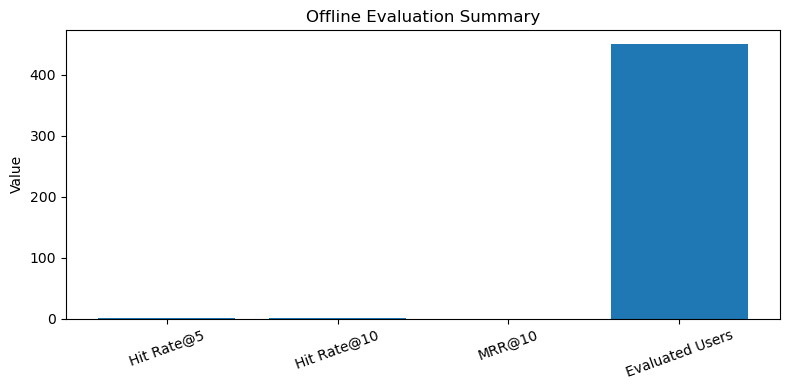

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(summary_metrics['metric'], summary_metrics['value'])
plt.title('Offline Evaluation Summary')
plt.ylabel('Value')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / 'evaluation_summary_bar.png', dpi=200, bbox_inches='tight')
plt.show()


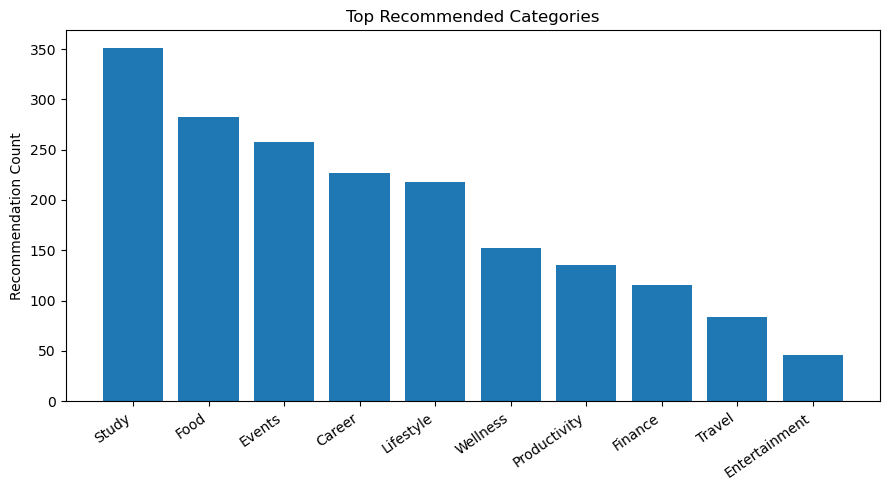

In [11]:
top_rec_categories = recommendation_snapshot_df['category'].value_counts().head(10)

plt.figure(figsize=(9, 5))
plt.bar(top_rec_categories.index, top_rec_categories.values)
plt.title('Top Recommended Categories')
plt.ylabel('Recommendation Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'top_recommended_categories.png', dpi=200, bbox_inches='tight')
plt.show()


In [12]:
persona_hit_df = evaluation_df.merge(users[['user_id', 'persona']], on='user_id', how='left')
persona_hit_summary = persona_hit_df.groupby('persona')[['hit_at_5', 'hit_at_10', 'reciprocal_rank']].mean().sort_values('hit_at_10', ascending=False)
persona_hit_summary


,hit_at_5,hit_at_10,reciprocal_rank
persona,,,
Pop Culture Browser,0.079365,0.079365,0.046825
Career Builder,0.035088,0.052632,0.009211
Budget Explorer,0.030769,0.046154,0.014103
Focused Planner,0.028571,0.042857,0.019524
Wellness Seeker,0.032258,0.032258,0.016129
Campus Connector,0.000000,0.000000,0.000000
Minimalist Achiever,0.000000,0.000000,0.000000
Weekend Adventurer,0.000000,0.000000,0.000000


## 9. Save outputs

In [13]:
summary_metrics.to_csv(METRICS_DIR / 'offline_summary_metrics.csv', index=False)
diagnostic_metrics.to_csv(METRICS_DIR / 'diagnostic_metrics.csv', index=False)
evaluation_df.to_csv(METRICS_DIR / 'evaluation_user_level_results.csv', index=False)
persona_top_categories.to_csv(METRICS_DIR / 'persona_top_categories.csv', index=False)
persona_hit_summary.reset_index().to_csv(METRICS_DIR / 'persona_hit_summary.csv', index=False)
recommendation_snapshot_df.to_csv(METRICS_DIR / 'evaluation_recommendation_snapshots.csv', index=False)

print('Saved evaluation outputs to results/metrics/')


Saved evaluation outputs to results/metrics/
